# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

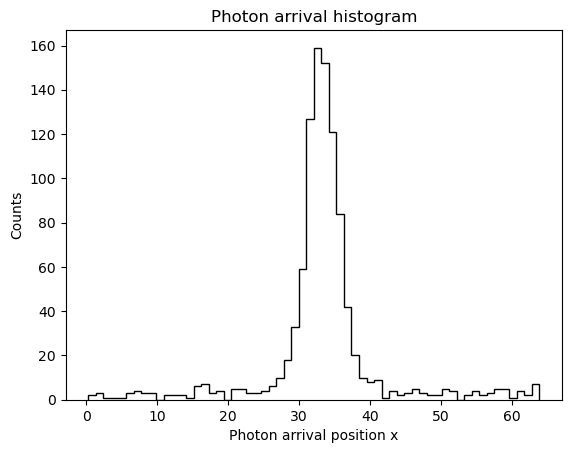

Naive estimate: x0 = 33.4282 ± 0.2519


In [2]:
bin_num= 60

import numpy as np
import matplotlib.pyplot as plt

d = np.genfromtxt('data/jhaff2.csv', names=True)
x = d['x']

plt.hist(x, bins=bin_num, histtype='step', color='black')
plt.xlabel("Photon arrival position x")
plt.ylabel("Counts")
plt.title("Photon arrival histogram")
plt.show()

N = len(x)
x_mean = np.mean(x)
s = np.std(x, ddof=1)
sigma = s / np.sqrt(N)

print(f"Naive estimate: x0 = {x_mean:.4f} ± {sigma:.4f}")

**ANSWER (a few sentences):**

The asnwer is biased, because not all photons come from the star in the first place, but a lot is due to background noise and would go in the dirrection of the sensor for the mean. The f bg is still pulling it, shows this model is not a good predictor. 

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

Naive estimate: x0 = 33.4282 ± 0.2519
Median estimate: x0_med = 33.2724
Naive estimate: x0 = 33.4282 ± 0.2519
Median estimate: x0_med = 33.2724


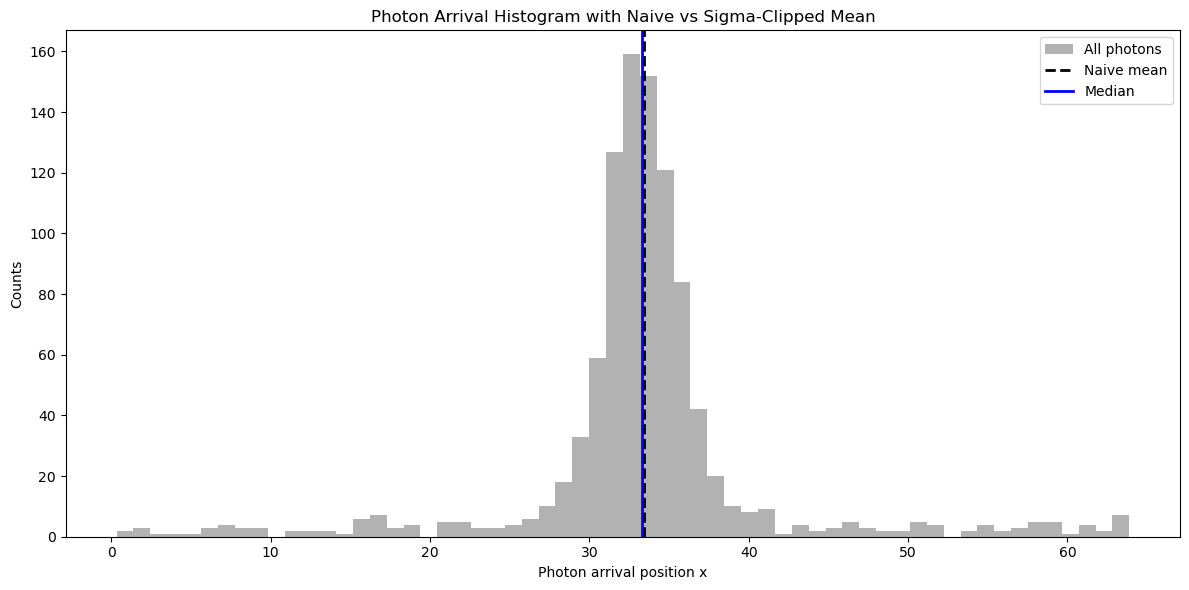

Sigma-clipped mean: x0 = 33.3124 ± 0.0868
Original N before clipping: 992
Effective N after clipping: 862
Points DESTROYED: 130


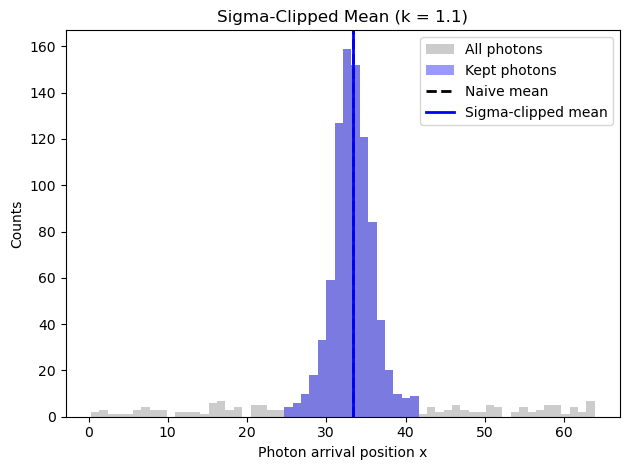


--- MLE Analysis Summary ---
x0_MLE   = 33.2845 ± 0.0845
f_bg_MLE = 0.1626 ± 0.0141
Cramér–Rao bound (Minimum achievable error) σ_x0 ≥ 0.1294


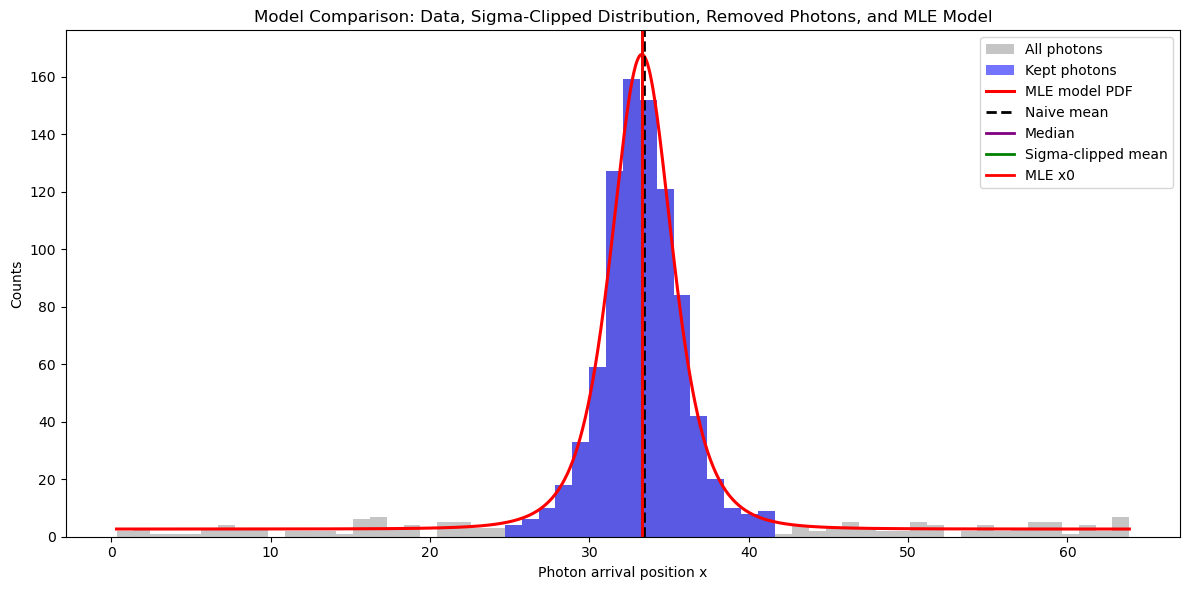

Sigma-clipped mean: x0 = 33.3124 ± 0.0868
Original N before clipping: 992
Effective N after clipping: 862
Points DESTROYED: 130
Naive estimate: x0 = 33.4282 ± 0.2519
Median estimate: x0_med = 33.2724

--- MLE Analysis Summary ---
x0_MLE   = 33.2845 ± 0.0845
f_bg_MLE = 0.1626 ± 0.0141
Cramér–Rao bound (Minimum achievable error) σ_x0 ≥ 0.1294


In [3]:
#1
x_mean = np.mean(x)
sigma = np.std(x, ddof=1) / np.sqrt(len(x))   # correct standard error

print(f"Naive estimate: x0 = {x_mean:.4f} ± {sigma:.4f}")
x_med = np.median(x)
print(f"Median estimate: x0_med = {x_med:.4f}")


sigma = np.std(x, ddof=1) / np.sqrt(len(x))   # correct standard error

print(f"Naive estimate: x0 = {x_mean:.4f} ± {sigma:.4f}")
x_med = np.median(x)
print(f"Median estimate: x0_med = {x_med:.4f}")

plt.figure(figsize=(12,6))
plt.hist(x, bins=bin_num, alpha=0.6, color='gray', label='All photons')
plt.axvline(x_mean, color='black', linestyle='--', linewidth=2, label='Naive mean')
plt.axvline(x_med, color='blue', linestyle='-', linewidth=2, label='Median')
plt.title("Photon Arrival Histogram with Naive vs Sigma-Clipped Mean")
plt.xlabel("Photon arrival position x")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()


#2
k_value = 1.1

def sigma_clipped_mean(x, k, tol=1e-4, max_iter=100):
    mask = np.ones_like(x, dtype=bool)
    mu_old = np.mean(x[mask])
    for _ in range(max_iter):
        mu = np.mean(x[mask])
        sigma_val = np.std(x[mask], ddof=1)
        new_mask = np.abs(x - mu) <= k * sigma_val
        if np.all(new_mask == mask) or np.abs(mu - mu_old) < tol:
            mask = new_mask
            mu = np.mean(x[mask])
            break
        mask = new_mask
        mu_old = mu
    N_eff = np.sum(mask)
    s_eff = np.std(x[mask], ddof=1)
    sigma_mean = s_eff / np.sqrt(N_eff)
    return mu, sigma_mean, mask

x_clip_mean, x_clip_sigma, clip_mask = sigma_clipped_mean(x, k_value)
print(f"Sigma-clipped mean: x0 = {x_clip_mean:.4f} ± {x_clip_sigma:.4f}")
print(f"Original N before clipping: {len(x)}")
print(f"Effective N after clipping: {np.sum(clip_mask)}")
print(f"Points DESTROYED: {len(x) - np.sum(clip_mask)}")

x_mean = np.mean(x)
x_clip_mean, x_clip_sigma, clip_mask = sigma_clipped_mean(x, k_value)
x_kept = x[clip_mask]
x_removed = x[~clip_mask]

counts, bin_edges = np.histogram(x, bins=bin_num)

plt.hist(x, bins=bin_edges, alpha=0.4, label='All photons', color='gray')
plt.hist(x_kept, bins=bin_edges, alpha=0.4, label='Kept photons', color='blue')
plt.axvline(x_mean, color='black', linestyle='--', linewidth=2, label='Naive mean')
plt.axvline(x_clip_mean, color='blue', linestyle='-', linewidth=2, label='Sigma-clipped mean')
plt.title(f"Sigma-Clipped Mean (k = {k_value})")
plt.xlabel("Photon arrival position x")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()


#3
from scipy.special import gamma
from scipy.optimize import minimize

beta = 2.5
r0 = 4.0
L = 64.0
norm_moffat = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

def p_single(x_arr, x0, fbg):
    return fbg/L + (1-fbg)*norm_moffat*(1 + ((x_arr-x0)/r0)**2)**(-beta)

def loglike(theta, x_arr):
    x0, fbg = theta
    if not (0.001 < fbg < 0.999):
        return np.inf
    p = p_single(x_arr, x0, fbg)
    if np.any(p <= 0):
        return np.inf
    return -np.sum(np.log(p))

theta0 = np.array([x_med, 0.5])
res = minimize(loglike, theta0, args=(x,), method='Nelder-Mead')
x0_mle, fbg_mle = res.x

def hessian_loglike_stable(theta, x_arr):
    npar = len(theta)
    H = np.zeros((npar, npar))
    eps = np.array([1e-4, 1e-5])
    for i in range(npar):
        for j in range(npar):
            dti = np.zeros_like(theta); dti[i] = eps[i]
            dtj = np.zeros_like(theta); dtj[j] = eps[j]
            fpp = loglike(theta + dti + dtj, x_arr)
            fpm = loglike(theta + dti - dtj, x_arr)
            fmp = loglike(theta - dti + dtj, x_arr)
            fmm = loglike(theta - dti - dtj, x_arr)
            H[i,j] = (fpp - fpm - fmp + fmm)/(4*eps[i]*eps[j])
    return H

H = hessian_loglike_stable(np.array([x0_mle, fbg_mle]), x)
cov = np.linalg.inv(H)
sigma_x0 = np.sqrt(max(0, cov[0,0]))
sigma_fbg = np.sqrt(max(0, cov[1,1]))

print("\n--- MLE Analysis Summary ---")
print(f"x0_MLE   = {x0_mle:.4f} ± {sigma_x0:.4f}")
print(f"f_bg_MLE = {fbg_mle:.4f} ± {sigma_fbg:.4f}")

def dp_dx0(x_arr, x0, fbg):
    star = norm_moffat*(1 + ((x_arr-x0)/r0)**2)**(-beta)
    dstar_dx0 = star*(-2*beta)*(x_arr-x0)/(r0**2 + (x_arr-x0)**2)
    return (1-fbg)*dstar_dx0

def dp_dfbg(x_arr, x0, fbg):
    return 1/L - norm_moffat*(1 + ((x_arr-x0)/r0)**2)**(-beta)

def fisher_matrix(x0, fbg, xmin=-32, xmax=32, ngrid=5000):
    xs = np.linspace(xmin, xmax, ngrid)
    p = p_single(xs, x0, fbg)
    dp0 = dp_dx0(xs, x0, fbg)
    dp1 = dp_dfbg(xs, x0, fbg)
    w = (xmax - xmin)/(ngrid - 1)
    I00 = np.sum((dp0**2)/p)*w
    I11 = np.sum((dp1**2)/p)*w
    I01 = np.sum((dp0*dp1)/p)*w
    return np.array([[I00, I01], [I01, I11]])

F = fisher_matrix(x0_mle, fbg_mle, xmin=-L/2, xmax=L/2)
CR_cov = np.linalg.inv(len(x)*F)
CR_sigma_x0 = np.sqrt(CR_cov[0,0])

print(f"Cramér–Rao bound (Minimum achievable error) σ_x0 ≥ {CR_sigma_x0:.4f}")

plt.figure(figsize=(12,6))
plt.hist(x, bins=bin_edges, alpha=0.45, color='gray', label='All photons')
plt.hist(x_kept, bins=bin_edges, alpha=0.55, color='blue', label='Kept photons')
xs = np.linspace(np.min(x), np.max(x), 2000)
p_mle = p_single(xs, x0_mle, fbg_mle)
bin_width = bin_edges[1] - bin_edges[0]
p_mle_scaled = p_mle * len(x) * bin_width
plt.plot(xs, p_mle_scaled, color='red', linewidth=2.2, label='MLE model PDF')
plt.axvline(x_mean, color='black', linestyle='--', linewidth=2, label='Naive mean')
plt.axvline(x_med, color='purple', linestyle='-', linewidth=2, label='Median')
plt.axvline(x_clip_mean, color='green', linestyle='-', linewidth=2, label='Sigma-clipped mean')
plt.axvline(x0_mle, color='red', linestyle='-', linewidth=2, label='MLE x0')
plt.title("Model Comparison: Data, Sigma-Clipped Distribution, Removed Photons, and MLE Model")
plt.xlabel("Photon arrival position x")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Sigma-clipped mean: x0 = {x_clip_mean:.4f} ± {x_clip_sigma:.4f}")
print(f"Original N before clipping: {len(x)}")
print(f"Effective N after clipping: {np.sum(clip_mask)}")
print(f"Points DESTROYED: {len(x) - np.sum(clip_mask)}")
print(f"Naive estimate: x0 = {x_mean:.4f} ± {sigma:.4f}")
print(f"Median estimate: x0_med = {x_med:.4f}")
print("\n--- MLE Analysis Summary ---")
print(f"x0_MLE   = {x0_mle:.4f} ± {sigma_x0:.4f}")
print(f"f_bg_MLE = {fbg_mle:.4f} ± {sigma_fbg:.4f}")
print(f"Cramér–Rao bound (Minimum achievable error) σ_x0 ≥ {CR_sigma_x0:.4f}")



--- Goodness-of-Fit Analysis ---
Total Chi-Squared (χ²): 54.2044
Degrees of Freedom (ν): 55
Reduced Chi-Squared (χ²_ν): 0.9855


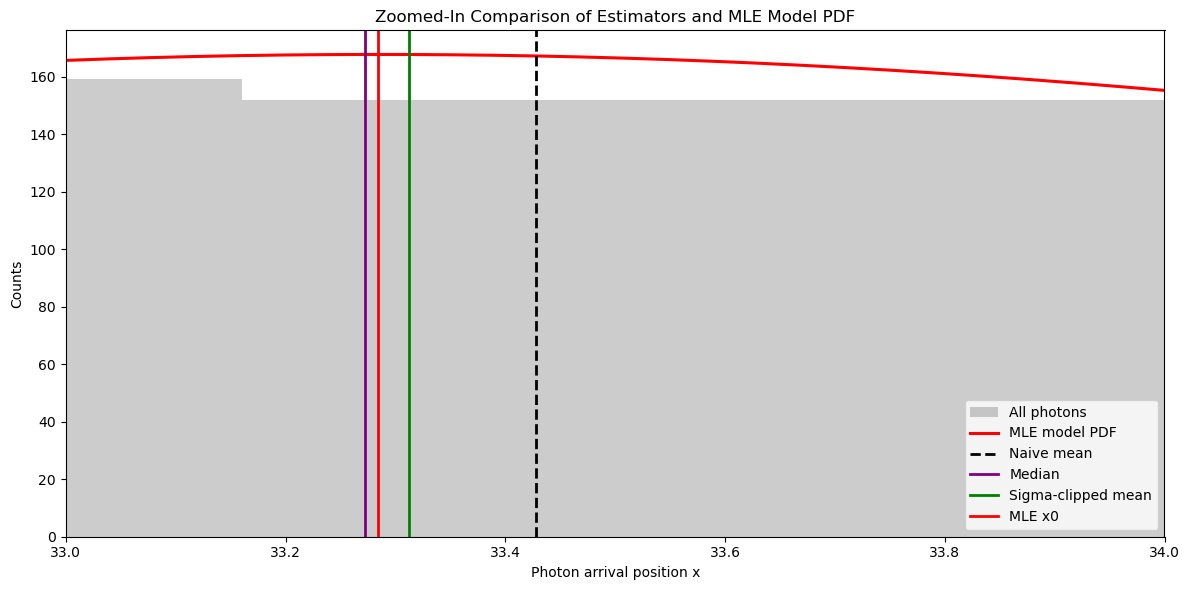

In [4]:
bin_midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

p_expected = p_single(bin_midpoints, x0_mle, fbg_mle)
E = p_expected * len(x) * bin_width

valid_bins = counts > 0
O_valid = counts[valid_bins]
E_valid = E[valid_bins]

chi_squared = np.sum(((O_valid - E_valid) ** 2) / O_valid)

fitted_parameters = 2
dof = len(O_valid) - fitted_parameters
reduced_chi_squared = chi_squared / dof

print(f"\n--- Goodness-of-Fit Analysis ---")
print(f"Total Chi-Squared (χ²): {chi_squared:.4f}")
print(f"Degrees of Freedom (ν): {dof}")
print(f"Reduced Chi-Squared (χ²_ν): {reduced_chi_squared:.4f}")
plt.figure(figsize=(12,6))


xmin = 33
xmax = 34

# Histogram (zoomed)
plt.hist(x, bins=bin_edges, alpha=0.4, color='gray', label='All photons')
plt.xlim(xmin, xmax)

# MLE model PDF (scaled to histogram)
xs = np.linspace(xmin, xmax, 2000)
p_mle = p_single(xs, x0_mle, fbg_mle)
bin_width = bin_edges[1] - bin_edges[0]
p_mle_scaled = p_mle * len(x) * bin_width
plt.plot(xs, p_mle_scaled, color='red', linewidth=2.2, label='MLE model PDF')

plt.axvline(x_mean, color='black', linestyle='--', linewidth=2, label='Naive mean')
plt.axvline(x_med, color='purple', linestyle='-', linewidth=2, label='Median')
plt.axvline(x_clip_mean, color='green', linestyle='-', linewidth=2, label='Sigma-clipped mean')
plt.axvline(x0_mle, color='red', linestyle='-', linewidth=2, label='MLE x0')

plt.title("Zoomed-In Comparison of Estimators and MLE Model PDF")
plt.xlabel("Photon arrival position x")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

Naive estimate: x0 = 33.4282 ± 0.2519
Median estimate: x0_med = 33.2724


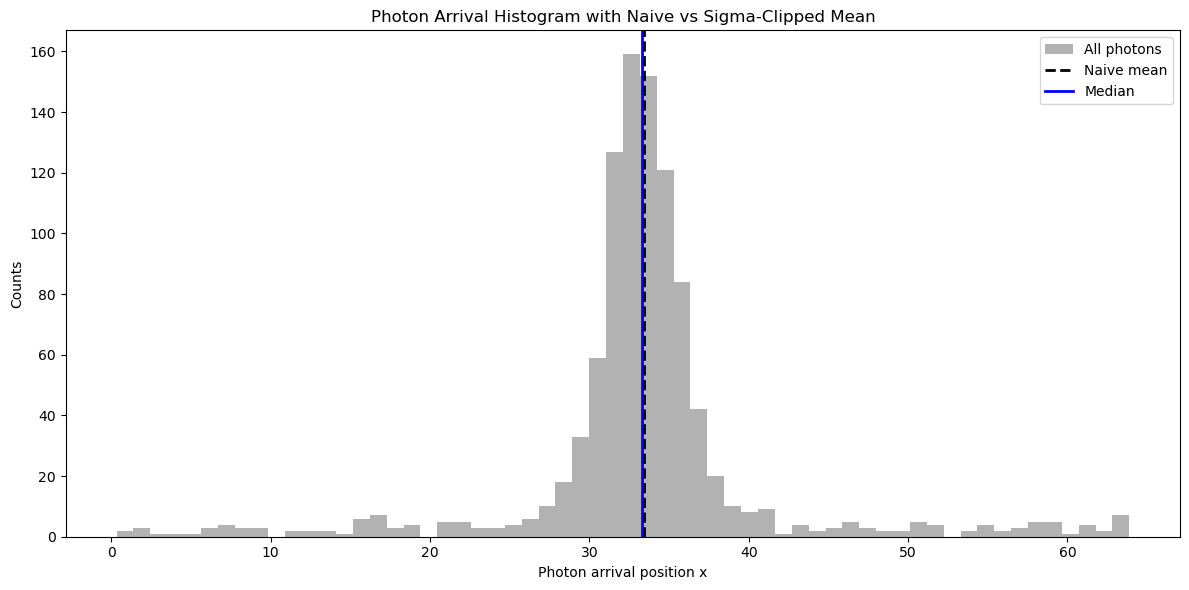

Sigma-clipped mean: x0 = 33.3124 ± 0.0868
Original N before clipping: 992
Effective N after clipping: 862
Points DESTROYED: 130


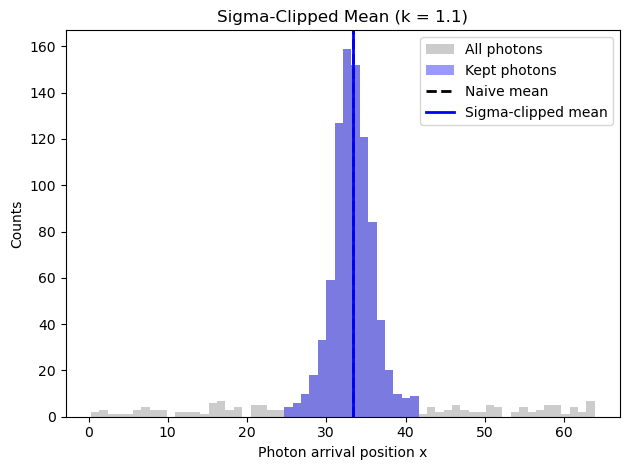


--- MLE Analysis Summary ---
x0_MLE   = 33.2845 ± 0.0845
f_bg_MLE = 0.1626 ± 0.0141

--- Lecture-style Fisher/Covariance (demo format) ---
Fisher matrix:
 [[0.06132678 0.07470366]
 [0.07470366 5.46333122]]
Covariance matrix:
 [[ 0.01671602 -0.00022857]
 [-0.00022857  0.00018764]]
Correlation matrix:
 [[ 1.         -0.12905892]
 [-0.12905892  1.        ]]
Cramér–Rao bound (demo-style) σ_x0 ≥ 0.1293


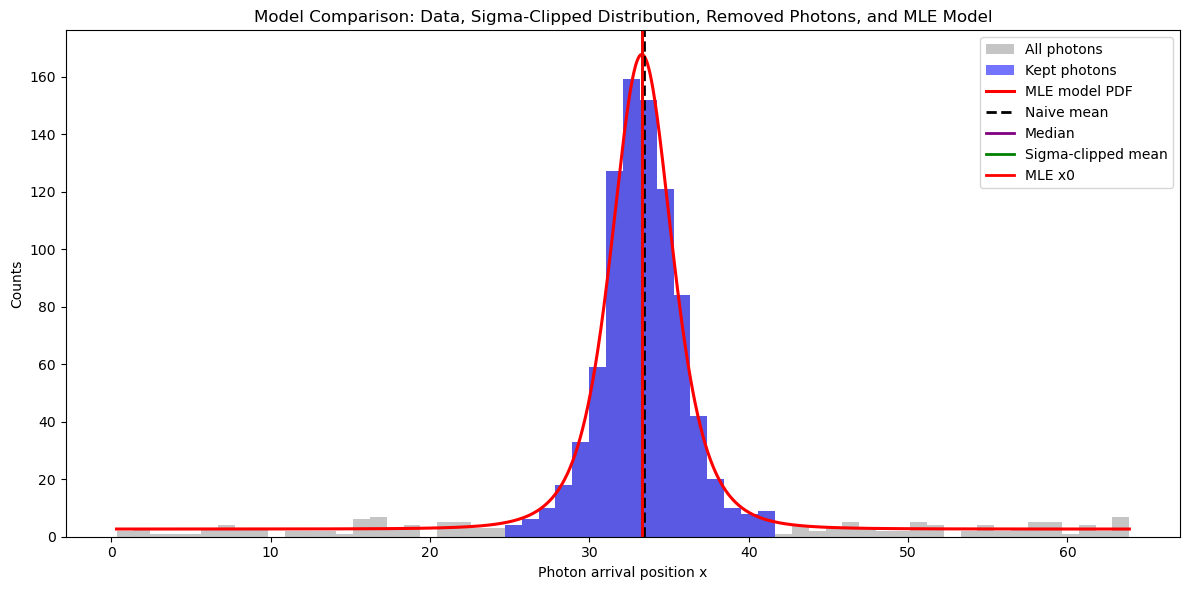

Sigma-clipped mean: x0 = 33.3124 ± 0.0868
Original N before clipping: 992
Effective N after clipping: 862
Points DESTROYED: 130
Naive estimate: x0 = 33.4282 ± 0.2519
Median estimate: x0_med = 33.2724

--- MLE Analysis Summary ---
x0_MLE   = 33.2845 ± 0.0845
f_bg_MLE = 0.1626 ± 0.0141
Cramér–Rao bound (Minimum achievable error) σ_x0 ≥ 0.1293


In [5]:
sigma = np.std(x, ddof=1) / np.sqrt(len(x))   # correct standard error

print(f"Naive estimate: x0 = {x_mean:.4f} ± {sigma:.4f}")
x_med = np.median(x)
print(f"Median estimate: x0_med = {x_med:.4f}")

plt.figure(figsize=(12,6))
plt.hist(x, bins=bin_num, alpha=0.6, color='gray', label='All photons')
plt.axvline(x_mean, color='black', linestyle='--', linewidth=2, label='Naive mean')
plt.axvline(x_med, color='blue', linestyle='-', linewidth=2, label='Median')
plt.title("Photon Arrival Histogram with Naive vs Sigma-Clipped Mean")
plt.xlabel("Photon arrival position x")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()


k_value = 1.1

def sigma_clipped_mean(x, k, tol=1e-4, max_iter=100):
    mask = np.ones_like(x, dtype=bool)
    mu_old = np.mean(x[mask])
    for _ in range(max_iter):
        mu = np.mean(x[mask])
        sigma_val = np.std(x[mask], ddof=1)
        new_mask = np.abs(x - mu) <= k * sigma_val
        if np.all(new_mask == mask) or np.abs(mu - mu_old) < tol:
            mask = new_mask
            mu = np.mean(x[mask])
            break
        mask = new_mask
        mu_old = mu
    N_eff = np.sum(mask)
    s_eff = np.std(x[mask], ddof=1)
    sigma_mean = s_eff / np.sqrt(N_eff)
    return mu, sigma_mean, mask

x_clip_mean, x_clip_sigma, clip_mask = sigma_clipped_mean(x, k_value)
print(f"Sigma-clipped mean: x0 = {x_clip_mean:.4f} ± {x_clip_sigma:.4f}")
print(f"Original N before clipping: {len(x)}")
print(f"Effective N after clipping: {np.sum(clip_mask)}")
print(f"Points DESTROYED: {len(x) - np.sum(clip_mask)}")

x_mean = np.mean(x)
x_clip_mean, x_clip_sigma, clip_mask = sigma_clipped_mean(x, k_value)
x_kept = x[clip_mask]
x_removed = x[~clip_mask]

counts, bin_edges = np.histogram(x, bins=bin_num)

plt.hist(x, bins=bin_edges, alpha=0.4, label='All photons', color='gray')
plt.hist(x_kept, bins=bin_edges, alpha=0.4, label='Kept photons', color='blue')
plt.axvline(x_mean, color='black', linestyle='--', linewidth=2, label='Naive mean')
plt.axvline(x_clip_mean, color='blue', linestyle='-', linewidth=2, label='Sigma-clipped mean')
plt.title(f"Sigma-Clipped Mean (k = {k_value})")
plt.xlabel("Photon arrival position x")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()


from scipy.special import gamma
from scipy.optimize import minimize

beta = 2.5
r0 = 4.0
L = 64.0
norm_moffat = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

def p_single(x_arr, x0, fbg):
    return fbg/L + (1-fbg)*norm_moffat*(1 + ((x_arr-x0)/r0)**2)**(-beta)

def loglike(theta, x_arr):
    x0, fbg = theta
    if not (0.001 < fbg < 0.999):
        return np.inf
    p = p_single(x_arr, x0, fbg)
    if np.any(p <= 0):
        return np.inf
    return -np.sum(np.log(p))

theta0 = np.array([x_med, 0.5])
res = minimize(loglike, theta0, args=(x,), method='Nelder-Mead')
x0_mle, fbg_mle = res.x

def hessian_loglike_stable(theta, x_arr):
    npar = len(theta)
    H = np.zeros((npar, npar))
    eps = np.array([1e-4, 1e-5])
    for i in range(npar):
        for j in range(npar):
            dti = np.zeros_like(theta); dti[i] = eps[i]
            dtj = np.zeros_like(theta); dtj[j] = eps[j]
            fpp = loglike(theta + dti + dtj, x_arr)
            fpm = loglike(theta + dti - dtj, x_arr)
            fmp = loglike(theta - dti + dtj, x_arr)
            fmm = loglike(theta - dti - dtj, x_arr)
            H[i,j] = (fpp - fpm - fmp + fmm)/(4*eps[i]*eps[j])
    return H

H = hessian_loglike_stable(np.array([x0_mle, fbg_mle]), x)
cov = np.linalg.inv(H)
sigma_x0 = np.sqrt(max(0, cov[0,0]))
sigma_fbg = np.sqrt(max(0, cov[1,1]))

print("\n--- MLE Analysis Summary ---")
print(f"x0_MLE   = {x0_mle:.4f} ± {sigma_x0:.4f}")
print(f"f_bg_MLE = {fbg_mle:.4f} ± {sigma_fbg:.4f}")


def model_pdf(xs, theta):
    x0, fbg = theta
    return p_single(xs, x0, fbg)


def fisher_covariance_demo(theta, xs):
    theta = np.asarray(theta, float)
    npar = len(theta)
    h = np.array([1e-4, 1e-5])

    # Numerical derivatives dp/dtheta_i
    dp = []
    for i in range(npar):
        e = np.zeros(npar)
        e[i] = h[i]
        fp = model_pdf(xs, theta + e)
        fm = model_pdf(xs, theta - e)
        dp.append((fp - fm) / (2*h[i]))
    dp = np.array(dp)  # shape (npar, Npix)

    p = model_pdf(xs, theta)

    # Fisher matrix: integral of (dp_i dp_j / p)
    w = (xs[-1] - xs[0]) / (len(xs) - 1)
    I = np.zeros((npar, npar))
    for i in range(npar):
        for j in range(npar):
            I[i,j] = np.sum((dp[i] * dp[j]) / p) * w

    # Covariance = inverse Fisher / N photons
    C = np.linalg.inv(I * len(x))

    # Correlation matrix
    R = C / np.sqrt(np.outer(np.diag(C), np.diag(C)))

    return I, C, R

xs = np.linspace(-L/2, L/2, 2000)

I_demo, C_demo, R_demo = fisher_covariance_demo([x0_mle, fbg_mle], xs)

CR_sigma_x0_demo = np.sqrt(C_demo[0,0])

print("\n--- Lecture-style Fisher/Covariance (demo format) ---")
print("Fisher matrix:\n", I_demo)
print("Covariance matrix:\n", C_demo)
print("Correlation matrix:\n", R_demo)
print(f"Cramér–Rao bound (demo-style) σ_x0 ≥ {CR_sigma_x0_demo:.4f}")


plt.figure(figsize=(12,6))
plt.hist(x, bins=bin_edges, alpha=0.45, color='gray', label='All photons')
plt.hist(x_kept, bins=bin_edges, alpha=0.55, color='blue', label='Kept photons')
xs_plot = np.linspace(np.min(x), np.max(x), 2000)
p_mle = p_single(xs_plot, x0_mle, fbg_mle)
bin_width = bin_edges[1] - bin_edges[0]
p_mle_scaled = p_mle * len(x) * bin_width
plt.plot(xs_plot, p_mle_scaled, color='red', linewidth=2.2, label='MLE model PDF')
plt.axvline(x_mean, color='black', linestyle='--', linewidth=2, label='Naive mean')
plt.axvline(x_med, color='purple', linestyle='-', linewidth=2, label='Median')
plt.axvline(x_clip_mean, color='green', linestyle='-', linewidth=2, label='Sigma-clipped mean')
plt.axvline(x0_mle, color='red', linestyle='-', linewidth=2, label='MLE x0')
plt.title("Model Comparison: Data, Sigma-Clipped Distribution, Removed Photons, and MLE Model")
plt.xlabel("Photon arrival position x")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Sigma-clipped mean: x0 = {x_clip_mean:.4f} ± {x_clip_sigma:.4f}")
print(f"Original N before clipping: {len(x)}")
print(f"Effective N after clipping: {np.sum(clip_mask)}")
print(f"Points DESTROYED: {len(x) - np.sum(clip_mask)}")
print(f"Naive estimate: x0 = {x_mean:.4f} ± {sigma:.4f}")
print(f"Median estimate: x0_med = {x_med:.4f}")
print("\n--- MLE Analysis Summary ---")
print(f"x0_MLE   = {x0_mle:.4f} ± {sigma_x0:.4f}")
print(f"f_bg_MLE = {fbg_mle:.4f} ± {sigma_fbg:.4f}")
print(f"Cramér–Rao bound (Minimum achievable error) σ_x0 ≥ {CR_sigma_x0_demo:.4f}")


**FINAL ANSWER:** x_0 = 33.2845 ± 0.0845 px ,  f_bg = 0.1626 ± 0.0141, Cramér–Rao bound σ_x0 ≥ 0.1293
I used the MLE
**Justification and uncertainty method (a short paragraph):**

1. Definitely not unbiased, it suffers the same bais from part one. It is still shifted or skewed in one direction,just now using the median, whichhas the same problem but in a different way. 

2. The k cutoff is a rough estimated I determined by eye. The number of points actually cut out is not based in hard statistics, just vibes. Could bemore precise, but now the background noise has been removed from the tails, but not from the middle section. Also, once comparing to the curve from part 3, its clear I made my cuttoff to exclusionary. I graphed it many times with histograms to see what the data was actually doing. I also ran a chi2 analysis to see how well the curve was fitting the bins. I used a fisher matrix and some supporting functions to get the errors. 

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

1. Closure will happen when a random true value is generated and all tests are rerun off of them, and then I will compare statistics to see if mine match the already known one. This will tell me if my functionsa re generating correctly. The function is going to simulate photons that are both from the star and background noise. If its far from the true value, or the error is crazy high, it will fail. 
2. I will run the Monte-Carlo estimation for mutliple simulations and for each of the methods that are possible. This will give me a distribution of their bias and efficiency, and I will judge which looks best.  If varience is huge, or doesn't converge, it will be wrong. It should be around the target number then barely be off from that pervious number over and over. 
3. I will check coverage by reruning these numbers and seeing how often they fall within the already determined error bars,and that will be my coverage. It will be wrong if the error bars dont contain the simulated data nearly enough or much at all. 
4. sensitivity will be checked by feeding it wrong data and seeing what happens. a wrong model will be made if a small variation in one of those parameters makes it go crazy, so in theory, the answer should still be consistent regardless of change. 

In [6]:
import numpy as np
from scipy.special import gamma
from scipy.optimize import minimize

beta = 2.5
r0 = 4.0
L = 64.0
nu = 2*beta - 1

N = 1000
M = 500

x0_true = 5.0
fbg_true = 0.16

norm_moffat = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

def simulate_photons():
    N_bg = int(N * fbg_true)
    N_star = N - N_bg
    bg = np.random.uniform(-L/2, L/2, N_bg)
    t = np.random.standard_t(df=nu, size=N_star)
    star = x0_true + t * (r0 / np.sqrt(nu))
    star = np.clip(star, -L/2, L/2)
    return np.concatenate([bg, star])

def naive_mean(x):
    return np.mean(x), np.std(x, ddof=1)/np.sqrt(len(x))

def median_est(x):
    return np.median(x), 1.253*np.std(x, ddof=1)/np.sqrt(len(x))

def sigma_clipped_mean(x, k=0.95):
    mask = np.ones_like(x, bool)
    mu = np.mean(x)          # ensure mu is defined
    mu_old = mu
    while True:
        if np.sum(mask) <= 1:
            break
        mu = np.mean(x[mask])
        sigma = np.std(x[mask], ddof=1)
        new_mask = np.abs(x - mu) <= k*sigma
        if np.all(new_mask == mask) or abs(mu - mu_old) < 1e-4:
            break
        mask = new_mask
        mu_old = mu
    if np.sum(mask) > 1:
        sigma_mean = np.std(x[mask], ddof=1)/np.sqrt(np.sum(mask))
    else:
        sigma_mean = np.nan
    return mu, sigma_mean

def p_single(x_arr, x0, fbg):
    return fbg/L + (1-fbg)*norm_moffat*(1 + ((x_arr-x0)/r0)**2)**(-beta)

def loglike(theta, x_arr):
    x0, fbg = theta
    if not (0.001 < fbg < 0.999):
        return np.inf
    p = p_single(x_arr, x0, fbg)
    if np.any(p <= 0):
        return np.inf
    return -np.sum(np.log(p))

def mle_est(x):
    res = minimize(loglike, [np.median(x), 0.5], args=(x,), method='Nelder-Mead')
    x0_mle, fbg_mle = res.x
    eps = np.array([1e-4, 1e-5])
    H = np.zeros((2,2))
    for i in range(2):
        for j in range(2):
            dti = np.zeros(2); dti[i] = eps[i]
            dtj = np.zeros(2); dtj[j] = eps[j]
            fpp = loglike(res.x + dti + dtj, x)
            fpm = loglike(res.x + dti - dtj, x)
            fmp = loglike(res.x - dti + dtj, x)
            fmm = loglike(res.x - dti - dtj, x)
            H[i,j] = (fpp - fpm - fmp + fmm)/(4*eps[i]*eps[j])
    try:
        inv_H = np.linalg.inv(H)
        sigma_x0 = np.sqrt(inv_H[0,0]) if inv_H[0,0] > 0 else np.nan
    except np.linalg.LinAlgError:
        sigma_x0 = np.nan
    return x0_mle, sigma_x0

# --- Closure test ---
x_closure = simulate_photons()

nm, ns = naive_mean(x_closure)
md, ms = median_est(x_closure)
sc, ss = sigma_clipped_mean(x_closure)
ml, ms_ml = mle_est(x_closure)

print("\n=== Closure Test ===")
print(f"True x0 = {x0_true:.4f}")
print(f"Naive mean:        {nm:.4f}  (error = {nm - x0_true:+.4f})")
print(f"Median:            {md:.4f}  (error = {md - x0_true:+.4f})")
print(f"Sigma-clipped:     {sc:.4f}  (error = {sc - x0_true:+.4f})")
print(f"MLE:               {ml:.4f}  (error = {ml - x0_true:+.4f})")

# --- Monte Carlo storage ---
naive_vals, median_vals, clip_vals, mle_vals = [], [], [], []
naive_sig, median_sig, clip_sig, mle_sig = [], [], [], []

# --- Monte Carlo loop ---
for _ in range(M):
    x = simulate_photons()
    nm, ns = naive_mean(x)
    md, ms = median_est(x)
    sc, ss = sigma_clipped_mean(x)
    ml, ms_ml = mle_est(x)

    naive_vals.append(nm);   naive_sig.append(ns)
    median_vals.append(md);  median_sig.append(ms)
    clip_vals.append(sc);    clip_sig.append(ss)
    mle_vals.append(ml);     mle_sig.append(ms_ml)

# --- Bias & variance ---
def stats(arr):
    arr = np.array(arr)
    arr = arr[np.isfinite(arr)]
    return np.mean(arr), np.var(arr), np.mean(arr) - x0_true

print("\n=== Monte Carlo Bias & Variance ===")
print("Naive mean:", stats(naive_vals))
print("Median:", stats(median_vals))
print("Sigma-clipped:", stats(clip_vals))
print("MLE:", stats(mle_vals))

# --- Coverage ---
def coverage(vals, sigs):
    vals = np.array(vals)
    sigs = np.array(sigs)
    valid = np.isfinite(vals) & np.isfinite(sigs)
    return np.mean((x0_true >= vals[valid] - sigs[valid]) & (x0_true <= vals[valid] + sigs[valid]))

print("\n=== Coverage ===")
print("Naive:", coverage(naive_vals, naive_sig))
print("Median:", coverage(median_vals, median_sig))
print("Sigma-clipped:", coverage(clip_vals, clip_sig))
print("MLE:", coverage(mle_vals, mle_sig))

# --- Sensitivity ---
def mle_wrong_model(x_arr, beta_wrong, r0_wrong):
    norm_wrong = gamma(beta_wrong)/(r0_wrong*np.sqrt(np.pi)*gamma(beta_wrong-0.5))
    def p_wrong(xs, x0, fbg):
        return fbg/L + (1-fbg)*norm_wrong*(1 + ((xs-x0)/r0_wrong)**2)**(-beta_wrong)
    def ll_wrong(theta):
        x0, fbg = theta
        if not (0.001 < fbg < 0.999): return np.inf
        p = p_wrong(x_arr, x0, fbg)
        if np.any(p <= 0): return np.inf
        return -np.sum(np.log(p))
    return minimize(ll_wrong, [np.median(x_arr), 0.5], method='Nelder-Mead').x[0]

print("\n=== Sensitivity ===")
x_test = simulate_photons()
print("MLE correct model:", mle_est(x_test)[0])
print("MLE beta+0.2:", mle_wrong_model(x_test, beta+0.2, r0))
print("MLE beta-0.2:", mle_wrong_model(x_test, beta-0.2, r0))
print("MLE r0+0.5:", mle_wrong_model(x_test, beta, r0+0.5))
print("MLE r0-0.5:", mle_wrong_model(x_test, beta, r0-0.5))



=== Closure Test ===
True x0 = 5.0000
Naive mean:        4.0363  (error = -0.9637)
Median:            4.7899  (error = -0.2101)
Sigma-clipped:     4.0363  (error = -0.9637)
MLE:               4.9033  (error = -0.0967)

=== Monte Carlo Bias & Variance ===
Naive mean: (np.float64(4.192091857006463), np.float64(0.06254176801984318), np.float64(-0.8079081429935373))
Median: (np.float64(4.922212377374945), np.float64(0.01006061604615591), np.float64(-0.07778762262505534))
Sigma-clipped: (np.float64(4.192091857006463), np.float64(0.06254176801984318), np.float64(-0.8079081429935373))
MLE: (np.float64(4.996070765469727), np.float64(0.007934519745573047), np.float64(-0.003929234530272829))

=== Coverage ===
Naive: 0.006
Median: 0.992
Sigma-clipped: 0.006
MLE: 0.662

=== Sensitivity ===
MLE correct model: 5.036789911949436
MLE beta+0.2: 5.036398447850181
MLE beta-0.2: 5.037225386372002
MLE r0+0.5: 5.039353007388408
MLE r0-0.5: 5.033578786468027


**WHAT THE CHECKS FOUND:**

It is clear that the MLE is by far the best estimator. The bias is the lowest for the MLE and it has the lowest varience. The MLE for coverage for the one sigma is good considering the perfect coverage is 64% And the sensitivity is really good for the MLE. All of the other ones have worse parameters than this by far. MLE is the best. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

I used Copilot to help with the statistics formulas in part 1, I mostly used it to fill and get functions related to statstics, but tripple checked the arguments entered. I simply didn't know the easiest stats equations to use, and made Copiolet tell me functions for standard dev. For part 1, it told me to use 1 degree of freedom instead of the default of 0. I was suspicous, so did research. Since I'm not taking the satdnard dev.of all the data but  instead of the mean, that actually would make sense, so I kept it. Also gave me 40 bins, which I thought 35 or so was better by messing with it.

For Part 2, I used it to trouble shoot why my code wasn't working, and it added a lot of stuff to my functions, and still didn't work. I then looked at lecture slides, and finally plugged it into google's AI what copilot gave me which then replaced one median with a sum and it started giving me different data from the asmwer in part 1. It also had the bin sizes all wrong when I tried to graph it, which I had to fix. Also, the analysis was completely nonsensical and it really had no idea what was going on. Finally, for the rest of that question, I asked copilot to generate me functions based on the equations I entered to save a lot of time from having to manually type it all out. It made some mistakes here too, and I had to ask it to make all the plots in code so I could check what was going on. It continued to give me error messages and confused parts 2 and 3 a lot, so I had to flip between. I asked it to explain to be exatcly why it was using some functions and why I was getting the same plots. I tested chnaging a lot of variables. At the very end, I asked it to simplify the code as much as possible as it was extremely long. I also had it run me a chi squared analysis so I could see how good my data was looking in comparison to other things.

After coming up with the methods of verification, I asked copilot to generate me code that would actually conduct it. The rest of the analysis was my own. I did have to use google AI to bug fix some of the code and reformat it. 
